# Proposition 2 (Fixed-Mean Head): NN Encoder, Finite Samples, GD

This notebook empirically validates Proposition 2 in the **fixed-mean** regime.

We train only the encoder by GD on
\[\mathcal{L}(\theta)=\frac12\,\mathbb{E}_n\|f_\theta(X)-Y\mu\|_2^2\]

with fixed \($\mu\in\mathbb{R}^{d_z}$\).

Proposition 2 predicts:
- \($g(t):=\mathbb{E}[Yf_t(X)]$\) converges to \($\kappa\mu$\), where \($\kappa=\mathbb{E}[\tanh^2(m^\top X)]$\).
- \($g(t)-\kappa\mu$\) decays exponentially (continuous-time slope \($-1$\) for \($\log\|g(t)-\kappa\mu\|$\)).
- \($f_t$\) converges to \($f_\infty(x)=\eta(x)\mu$\), \($\eta(x)=\tanh(m^\top x)$\).


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)


In [2]:
# Configuration
cfg = {
    "m_values": [1.0, 2.0],
    "d_in": 8,
    "d_latent": 4,
    "mu_norm": 1.0,
    "n_train": 4000,
    "steps": 3000,
    "lr": 6e-3,
    "hidden": 128,
    "depth": 2,
    "fit_start_step": 1,
    "seed": 7,
    "device": "cuda",
    "print_every": 500,
}


In [3]:
def make_unit_vector(dim, seed, device="cpu"):
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    v = torch.randn(dim, generator=g, device=device)
    return v / (torch.linalg.norm(v) + 1e-12)


def make_dataset(n, d_in, m, seed, device="cpu"):
    g = torch.Generator(device=device)
    g.manual_seed(seed)

    m_vec = m * make_unit_vector(d_in, seed=seed + 1000, device=device)
    y = torch.where(torch.rand(n, generator=g, device=device) < 0.5, -1.0, 1.0).view(-1, 1)
    eps = torch.randn(n, d_in, generator=g, device=device)
    x = y * m_vec.view(1, -1) + eps

    eta = torch.tanh(x @ m_vec.view(-1, 1))  # (n,1)
    return x, y, m_vec, eta


class EncoderNN(torch.nn.Module):
    def __init__(self, d_in=8, d_latent=4, hidden=128, depth=2):
        super().__init__()
        layers = []
        in_dim = d_in
        for _ in range(depth):
            layers.append(torch.nn.Linear(in_dim, hidden))
            layers.append(torch.nn.ReLU())
            in_dim = hidden
        layers.append(torch.nn.Linear(in_dim, d_latent))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def run_single_prop2(m, d_in, d_latent, mu_norm, n_train, steps, lr, hidden, depth, fit_start_step, seed, device="cpu", print_every=500):
    x, y, m_vec, eta = make_dataset(n=n_train, d_in=d_in, m=m, seed=seed, device=device)

    # Fixed head mean vector mu
    mu = mu_norm * make_unit_vector(d_latent, seed=seed + 2000, device=device)

    # Theory constants/targets
    with torch.no_grad():
        kappa = torch.mean(eta ** 2).item()
    g_target = kappa * mu                      # (d_latent,)
    f_target = eta * mu.view(1, -1)           # (n, d_latent)

    model = EncoderNN(d_in=d_in, d_latent=d_latent, hidden=hidden, depth=depth).to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr)

    hist = {
        "norm_g": np.zeros(steps),
        "norm_g_target": np.zeros(steps),
        "norm_g_gap": np.zeros(steps),
        "norm_f_gap": np.zeros(steps),
        "loss": np.zeros(steps),
        "kappa": kappa,
        "target_norm": torch.linalg.norm(g_target).item(),
    }

    eps_num = 1e-16

    for t in range(steps):
        f = model(x)
        resid = f - y * mu.view(1, -1)
        loss = 0.5 * torch.mean(torch.sum(resid ** 2, dim=1))

        opt.zero_grad()
        loss.backward()
        opt.step()

        with torch.no_grad():
            f_now = model(x)
            g_vec = torch.mean(y * f_now, dim=0)

            g_gap = torch.linalg.norm(g_vec - g_target).item()
            f_gap = torch.sqrt(torch.mean(torch.sum((f_now - f_target) ** 2, dim=1))).item()

            hist["norm_g"][t] = torch.linalg.norm(g_vec).item()
            hist["norm_g_target"][t] = torch.linalg.norm(g_target).item()
            hist["norm_g_gap"][t] = max(g_gap, eps_num)
            hist["norm_f_gap"][t] = max(f_gap, eps_num)
            hist["loss"][t] = loss.item()

        if (t + 1) % print_every == 0:
            print(
                f"m={m:.2f} step {t+1:4d}/{steps} "
                f"kappa={kappa:.4f} "
                f"||g||={hist['norm_g'][t]:.4e} "
                f"||g-kmu||={hist['norm_g_gap'][t]:.4e} "
                f"||f-f*||={hist['norm_f_gap'][t]:.4e} "
                f"loss={hist['loss'][t]:.4e}"
            )

    return hist


In [4]:
all_hist = {}
for m in cfg["m_values"]:
    print("=" * 80)
    all_hist[m] = run_single_prop2(
        m=m,
        d_in=cfg["d_in"],
        d_latent=cfg["d_latent"],
        mu_norm=cfg["mu_norm"],
        n_train=cfg["n_train"],
        steps=cfg["steps"],
        lr=cfg["lr"],
        hidden=cfg["hidden"],
        depth=cfg["depth"],
        fit_start_step=cfg["fit_start_step"],
        seed=cfg["seed"],
        device=cfg["device"],
        print_every=cfg["print_every"],
    )


m=1.00 step  500/3000 kappa=0.5532 ||g||=5.0974e-01 ||g-kmu||=4.3518e-02 ||f-f*||=2.2365e-01 loss=2.4698e-01
m=1.00 step 1000/3000 kappa=0.5532 ||g||=5.1939e-01 ||g-kmu||=3.3855e-02 ||f-f*||=2.0334e-01 loss=2.4162e-01
m=1.00 step 1500/3000 kappa=0.5532 ||g||=5.2463e-01 ||g-kmu||=2.8604e-02 ||f-f*||=1.8898e-01 loss=2.3802e-01
m=1.00 step 2000/3000 kappa=0.5532 ||g||=5.2858e-01 ||g-kmu||=2.4654e-02 ||f-f*||=1.7748e-01 loss=2.3524e-01
m=1.00 step 2500/3000 kappa=0.5532 ||g||=5.3199e-01 ||g-kmu||=2.1251e-02 ||f-f*||=1.6761e-01 loss=2.3287e-01
m=1.00 step 3000/3000 kappa=0.5532 ||g||=5.3493e-01 ||g-kmu||=1.8302e-02 ||f-f*||=1.5914e-01 loss=2.3084e-01
m=2.00 step  500/3000 kappa=0.9300 ||g||=8.3063e-01 ||g-kmu||=9.9353e-02 ||f-f*||=3.2733e-01 loss=8.6527e-02
m=2.00 step 1000/3000 kappa=0.9300 ||g||=8.4321e-01 ||g-kmu||=8.6780e-02 ||f-f*||=2.9883e-01 loss=7.7195e-02
m=2.00 step 1500/3000 kappa=0.9300 ||g||=8.5356e-01 ||g-kmu||=7.6430e-02 ||f-f*||=2.7513e-01 loss=6.9988e-02
m=2.00 step 2000/30

Slope summary: early fit iter< 200, late fit iter>= 1000
m=1.0  g_early=-1.05  g_late=-0.05  f_early=-0.80  f_late=-0.02
m=2.0  g_early=-1.83  g_late=-0.05  f_early=-0.92  f_late=-0.03
Final-value summary:
m=1.0  kappa=0.5532  ||kmu||=5.5322e-01  final ||g||=5.3493e-01  final ||g-kmu||=1.8302e-02  final ||f-f*||=1.5914e-01
m=2.0  kappa=0.9300  ||kmu||=9.2997e-01  final ||g||=8.8009e-01  final ||g-kmu||=4.9897e-02  final ||f-f*||=2.0876e-01


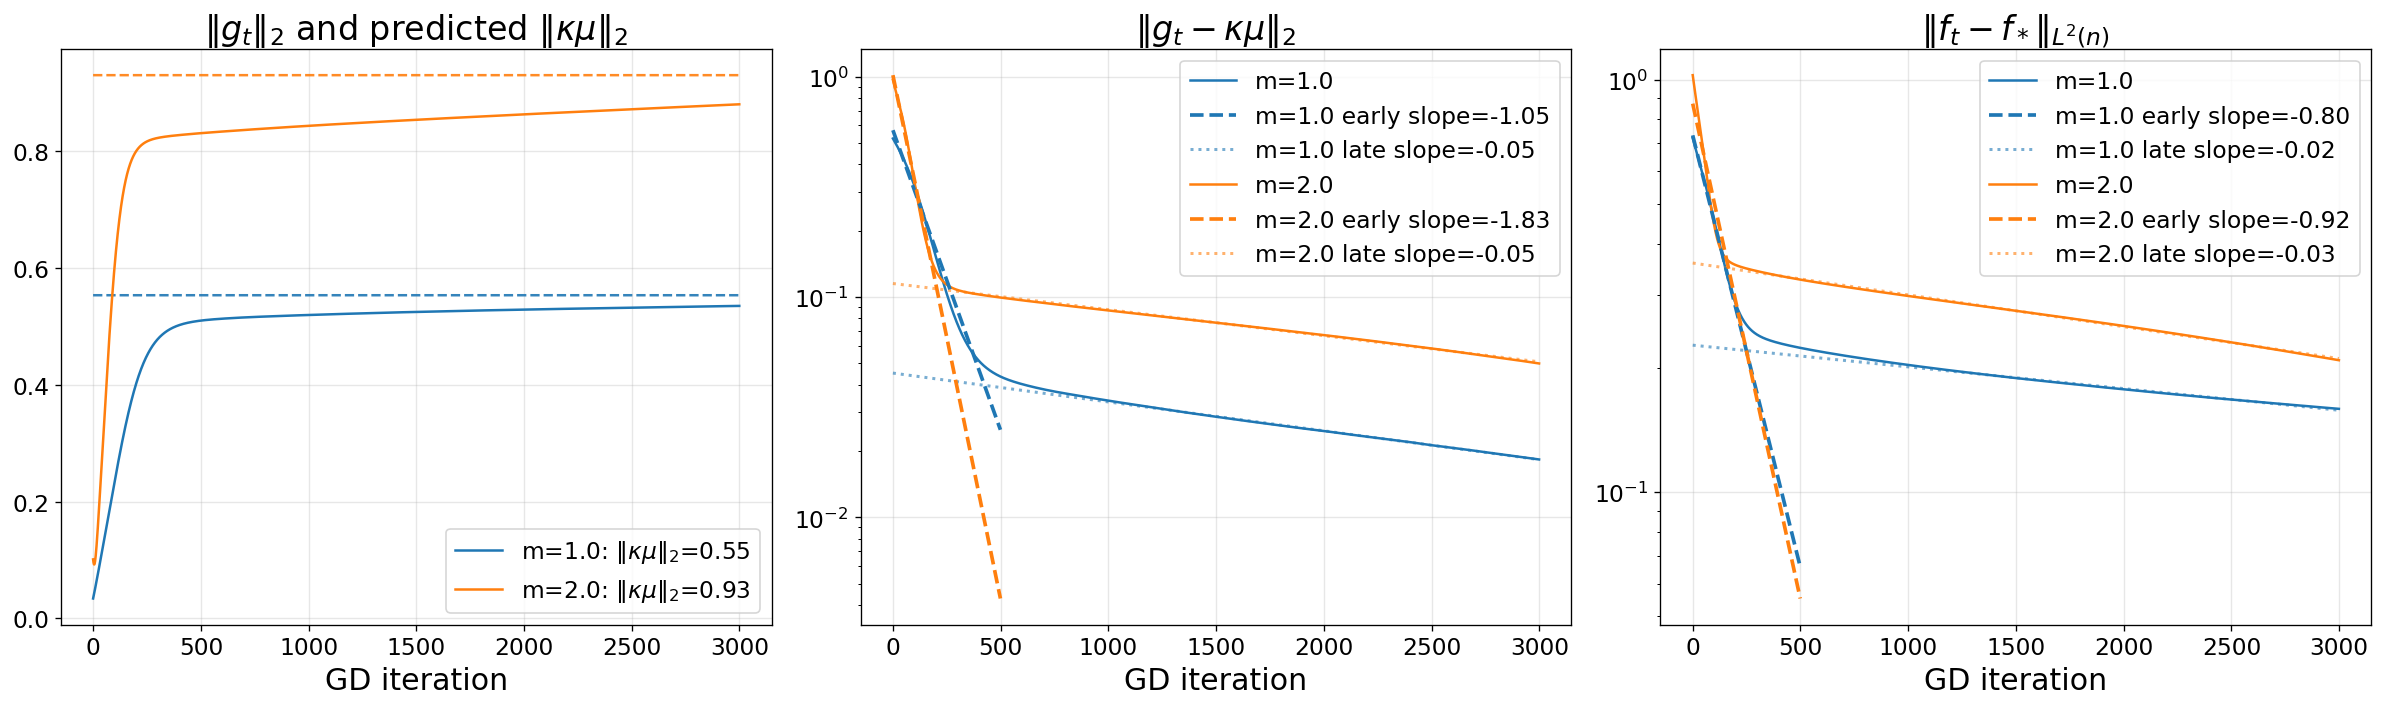

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=120)
title_fs = 20
label_fs = 18
tick_fs = 14
legend_fs = 14
fit_end_iter = 200
fit_late_start = 1000
display_early_end = 500
display_late_start = 0
slope_rows = []
for m in cfg["m_values"]:
    h = all_hist[m]
    # Panel 1: ||g_t|| with predicted limit ||kappa mu||
    line = axes[0].plot(h["norm_g"], label=rf"m={m}: $\|\kappa\mu\|_2$={h['target_norm']:.2f}")[0]
    axes[0].plot(h["norm_g_target"], linestyle="--", color=line.get_color(), alpha=0.9)
    # Panel 2: ||g_t - kappa mu|| (log scale) + two regression fits
    y_g = np.asarray(h["norm_g_gap"])
    n_g = np.arange(y_g.size)
    t_g = n_g * cfg["lr"]
    mask_g_early = np.isfinite(y_g) & (y_g > 0) & (n_g > 0) & (n_g <= fit_end_iter)
    slope_g_early, intercept_g_early = np.polyfit(t_g[mask_g_early], np.log(y_g[mask_g_early]), 1)
    fit_g_early = np.exp(intercept_g_early + slope_g_early * t_g)
    mask_g_late = np.isfinite(y_g) & (y_g > 0) & (n_g >= fit_late_start)
    slope_g_late, intercept_g_late = np.polyfit(t_g[mask_g_late], np.log(y_g[mask_g_late]), 1)
    fit_g_late = np.exp(intercept_g_late + slope_g_late * t_g)
    disp_mask_g_early = n_g < min(display_early_end, len(n_g))
    disp_mask_g_late = n_g >= display_late_start
    axes[1].plot(y_g, color=line.get_color(), label=f"m={m}")
    axes[1].plot(
        n_g[disp_mask_g_early], fit_g_early[disp_mask_g_early],
        linestyle="--", color=line.get_color(), alpha=1.0, linewidth=2.2, zorder=5,
        label=f"m={m} early slope={slope_g_early:.2f}"
    )
    axes[1].plot(
        n_g[disp_mask_g_late], fit_g_late[disp_mask_g_late],
        linestyle=":", color=line.get_color(), alpha=0.6, linewidth=1.8, zorder=3,
        label=f"m={m} late slope={slope_g_late:.2f}"
    )
    # Panel 3: ||f_t - f*|| (log scale) + two regression fits
    y_f = np.asarray(h["norm_f_gap"])
    n_f = np.arange(y_f.size)
    t_f = n_f * cfg["lr"]
    mask_f_early = np.isfinite(y_f) & (y_f > 0) & (n_f > 0) & (n_f <= fit_end_iter)
    slope_f_early, intercept_f_early = np.polyfit(t_f[mask_f_early], np.log(y_f[mask_f_early]), 1)
    fit_f_early = np.exp(intercept_f_early + slope_f_early * t_f)
    mask_f_late = np.isfinite(y_f) & (y_f > 0) & (n_f >= fit_late_start)
    slope_f_late, intercept_f_late = np.polyfit(t_f[mask_f_late], np.log(y_f[mask_f_late]), 1)
    fit_f_late = np.exp(intercept_f_late + slope_f_late * t_f)
    disp_mask_f_early = n_f < min(display_early_end, len(n_f))
    disp_mask_f_late = n_f >= display_late_start
    axes[2].plot(y_f, color=line.get_color(), label=f"m={m}")
    axes[2].plot(
        n_f[disp_mask_f_early], fit_f_early[disp_mask_f_early],
        linestyle="--", color=line.get_color(), alpha=1.0, linewidth=2.2, zorder=5,
        label=f"m={m} early slope={slope_f_early:.2f}"
    )
    axes[2].plot(
        n_f[disp_mask_f_late], fit_f_late[disp_mask_f_late],
        linestyle=":", color=line.get_color(), alpha=0.6, linewidth=1.8, zorder=3,
        label=f"m={m} late slope={slope_f_late:.2f}"
    )
    slope_rows.append((m, slope_g_early, slope_g_late, slope_f_early, slope_f_late))
axes[0].set_title(r"$\|g_t\|_2$ and predicted $\|\kappa\mu\|_2$", fontsize=title_fs)
axes[1].set_title(r"$\|g_t-\kappa\mu\|_2$", fontsize=title_fs)
axes[2].set_title(r"$\|f_t-f_*\|_{L^2(n)}$", fontsize=title_fs)
axes[1].set_yscale("log")
axes[2].set_yscale("log")
for ax in axes:
    ax.set_xlabel("GD iteration", fontsize=label_fs)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=legend_fs)
    ax.tick_params(axis="both", labelsize=tick_fs)
print(f"Slope summary: early fit iter< {fit_end_iter}, late fit iter>= {fit_late_start}")
for m, sg_e, sg_l, sf_e, sf_l in slope_rows:
    print(f"m={m:.1f}  g_early={sg_e:.2f}  g_late={sg_l:.2f}  f_early={sf_e:.2f}  f_late={sf_l:.2f}")
print("Final-value summary:")
for m in cfg["m_values"]:
    h = all_hist[m]
    print(
        f"m={m:.1f}  kappa={h['kappa']:.4f}  ||kmu||={h['target_norm']:.4e}  "
        f"final ||g||={h['norm_g'][-1]:.4e}  final ||g-kmu||={h['norm_g_gap'][-1]:.4e}  final ||f-f*||={h['norm_f_gap'][-1]:.4e}"
    )
plt.tight_layout()
plt.show()


## Notes

- This is a finite-sample approximation of Proposition 2 in the fixed-\(\mu\) regime.
- Panel 1 compares \($\|g_t\|_2$\) to the predicted limit \($\|\kappa\mu\|_2$\).
- Panels 2 and 3 are on log scale and include two fit lines each.
- Early slopes are fit on iterations `1..200` and displayed on `< 500`.
- Late slopes are fit on iterations `>= 1000` and displayed on `> 200`.
- Early fits are drawn above late fits for readability.
- Font sizes were increased for readability.
